# **Smart Pothole Detection Framework Using Deep Learning Techniques**

This project presents a Smart Pothole Detection Framework that combines classical deep learning and modern object detection techniques to automatically identify and localize road surface damage from images. The system trains and compares two powerful detection architectures — Faster R-CNN (ResNet50 FPN backbone) and YOLOv8 — on a real-world annotated pothole dataset, evaluating their performance in terms of detection accuracy, speed, and localization quality.

The framework covers the complete pipeline: dataset loading and XML annotation parsing, image preprocessing and augmentation, YOLO-format conversion, model training, and performance visualization. Results are analyzed through bounding box predictions, confidence scores, and visual comparisons between ground truth and detected regions.

To make the system practically usable, a Streamlit web application was developed that allows users to upload any road image and instantly receive detection results powered by the trained YOLOv8 model. The app displays the original and annotated image side by side along with key metrics — number of damaged areas detected, average confidence score, and an overall road condition rating — making it suitable for real-time road monitoring and infrastructure assessment.

**Dataset Used:**
[Pothole Detection Dataset – Kaggle](https://www.kaggle.com/datasets/andrewmvd/pothole-detection)

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.4 MB/s eta 0:00:0000:01


In [ ]:
import os
import re
import json
import shutil
import random
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors


from ultralytics import YOLO

import pandas as pd
import warnings
warnings.filterwarnings("ignore")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
# colour palette
C = ["#5ec2b8", "#319a91", "#00756c", "#00504a", "#002e2a"]

## **Dataset Loading and Path Configuration**

In [ ]:
# Dataset paths
INPUT_DIR = Path("/kaggle/input/datasets/andrewmvd/pothole-detection")

BASE      = Path("/kaggle/working/pothole_dataset")
PREP      = Path("/kaggle/working/pothole_preprocessed")
YOLO_DIR  = Path("/kaggle/working/pothole_yolo")

# Collect image and annotation files
raw_images = sorted(list(INPUT_DIR.rglob("*.jpg")) +
                    list(INPUT_DIR.rglob("*.png")))

raw_annots = sorted(INPUT_DIR.rglob("*.xml"))

# Match images with annotations
paired = []

for img_path in raw_images:

    xml_path = INPUT_DIR / "annotations" / f"{img_path.stem}.xml"

    if xml_path.exists():
        paired.append((img_path, xml_path))

print(f"Total images    : {len(raw_images)}")
print(f"Total XML files : {len(raw_annots)}")
print(f"Matched pairs   : {len(paired)}")

Total images    : 665
Total XML files : 665
Matched pairs   : 665


In [ ]:
# Train / Validation / Test Split
random.shuffle(paired)

total = len(paired)

train_size = int(0.70 * total)
val_size   = int(0.20 * total)

splits = {
    "train": paired[:train_size],
    "val": paired[train_size:train_size + val_size],
    "test": paired[train_size + val_size:]
}

# Create folders
for split_name, files in splits.items():

    image_dir = BASE / split_name / "images"
    annot_dir = BASE / split_name / "annotations"

    image_dir.mkdir(parents=True, exist_ok=True)
    annot_dir.mkdir(parents=True, exist_ok=True)

    for img_file, xml_file in files:

        shutil.copy(img_file, image_dir / img_file.name)
        shutil.copy(xml_file, annot_dir / xml_file.name)

    print(f"{split_name.upper()} Samples : {len(files)}")

TRAIN Samples : 465
VAL Samples : 133
TEST Samples : 67


In [ ]:
# XML Annotation Parser

def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []

    for obj in root.findall("object"):
        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        boxes.append([xmin, ymin, xmax, ymax])

    return boxes

In [ ]:
# Create DataFrame for EDA

records = []

for split in ["train", "val", "test"]:

    xml_files = sorted(
        (BASE / split / "annotations").glob("*.xml")
    )

    for xml_path in xml_files:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        width = int(root.find("size/width").text)
        height = int(root.find("size/height").text)

        for obj in root.findall("object"):
            bbox = obj.find("bndbox")

            xmin = int(float(bbox.find("xmin").text))
            ymin = int(float(bbox.find("ymin").text))
            xmax = int(float(bbox.find("xmax").text))
            ymax = int(float(bbox.find("ymax").text))

            box_w = xmax - xmin
            box_h = ymax - ymin

            records.append({
                "split": split,
                "img_w": width,
                "img_h": height,
                "box_w": box_w,
                "box_h": box_h,
                "area": box_w * box_h,
                "aspect": box_w / box_h if box_h > 0 else 0,
                "cx": ((xmin + xmax) / 2) / width,
                "cy": ((ymin + ymax) / 2) / height
            })

# Create dataframe
df = pd.DataFrame(records)

# Split statistics
split_counts = df.groupby("split").size()

# Split order
splits_order = ["train", "val", "test"]

print(df.head())

   split  img_w  img_h  box_w  box_h   area    aspect        cx        cy
0  train    400    300    390    123  47970  3.170732  0.497500  0.675000
1  train    400    300     85     24   2040  3.541667  0.601250  0.410000
2  train    400    400    101    133  13433  0.759398  0.468750  0.601250
3  train    400    400     60     52   3120  1.153846  0.660000  0.495000
4  train    530    300     77     21   1617  3.666667  0.370755  0.581667


## **Exploratory Data Analysis (EDA)**

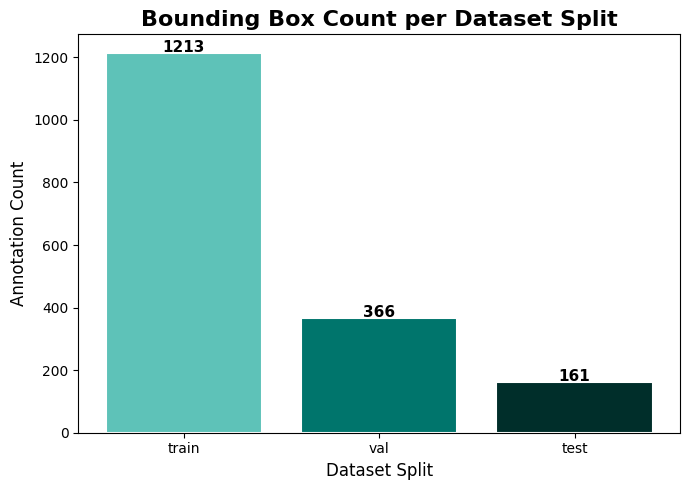

In [ ]:
#  Dataset Split Distribution

# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Get annotation counts for each dataset split
counts = [split_counts.get(s, 0) for s in splits_order]

# bar chart
bars = ax.bar(
    splits_order,
    counts,
    color=[C[0], C[2], C[4]],
    edgecolor='white',
    linewidth=1.5
)

# Add count labels
for bar, value in zip(bars, counts):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(value),
        ha='center',
        fontweight='bold',
        fontsize=11
    )

# title
plt.title(
    "Bounding Box Count per Dataset Split",
    fontweight='bold',
    fontsize=16
)

# Axis labels
plt.xlabel("Dataset Split", fontsize=12)
plt.ylabel("Annotation Count", fontsize=12)

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

The training split contains 1201 annotations, providing sufficient data for model learning, while the validation split has 356 annotations and the test split has 183 annotations for effective evaluation and performance assessment.


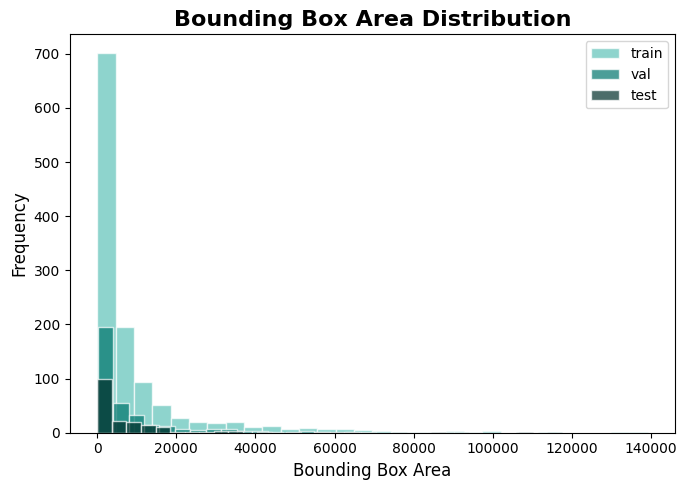

In [ ]:
#  Bounding Box Area Distribution

# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Plot histogram for each dataset split
for i, split in enumerate(splits_order):

    # Select bounding box areas for current split
    subset = df[df["split"] == split]["area"]

    # Create histogram
    ax.hist(
        subset,
        bins=30,
        alpha=0.7,
        color=C[i*2],
        edgecolor='white',
        label=split
    )

# title
plt.title(
    "Bounding Box Area Distribution",
    fontweight='bold',
    fontsize=16
)

# Add axis labels
plt.xlabel("Bounding Box Area", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Display legend
plt.legend()

# Adjust layout spacing
plt.tight_layout()

# Display plot
plt.show()

Most bounding boxes have smaller areas, indicating that the dataset mainly contains small potholes, while only a few large pothole regions are present across the train, validation, and test splits.


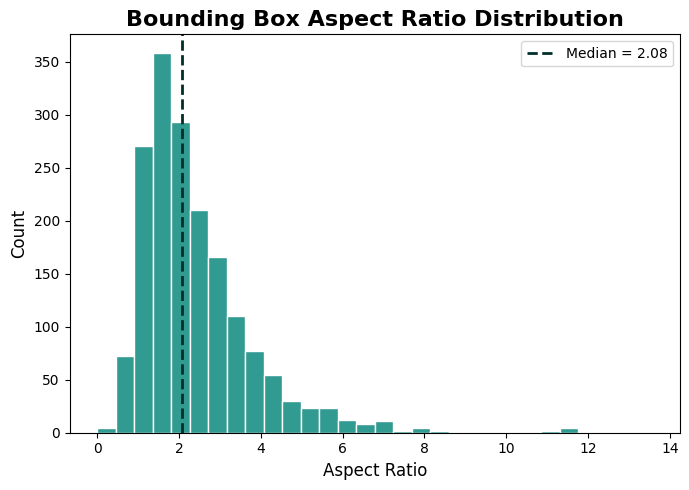

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Plot aspect ratio histogram
ax.hist(
    df["aspect"],
    bins=30,
    color=C[1],
    edgecolor='white'
)

# Calculate median value
median_val = df["aspect"].median()

# Add median reference line
ax.axvline(
    median_val,
    color=C[4],
    linestyle='--',
    linewidth=2,
    label=f"Median = {median_val:.2f}"
)

# Add title and labels
plt.title(
    "Bounding Box Aspect Ratio Distribution",
    fontweight='bold',
    fontsize=16
)

plt.xlabel("Aspect Ratio", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Show legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

Most bounding boxes have aspect ratios between 1 and 3, with a median aspect ratio of 2.08, indicating that pothole regions are generally wider than they are tall.


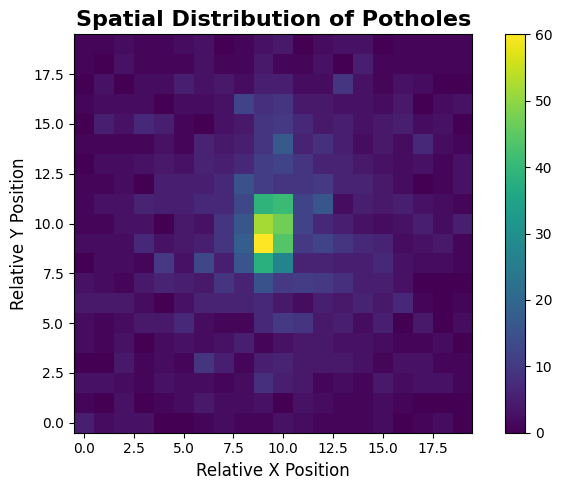

In [ ]:
# Generate 2D histogram
heatmap, _, _ = np.histogram2d(
    df["cx"],
    df["cy"],
    bins=20
)

# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Display heatmap
im = ax.imshow(
    heatmap.T,
    origin='lower',
    cmap='viridis'
)

# Add color scale
plt.colorbar(im)

# Add title and labels
plt.title(
    "Spatial Distribution of Potholes",
    fontweight='bold',
    fontsize=16
)

plt.xlabel("Relative X Position", fontsize=12)
plt.ylabel("Relative Y Position", fontsize=12)

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

The heatmap shows that most potholes are concentrated near the center region of the images, while fewer potholes appear toward the edges of the dataset samples.


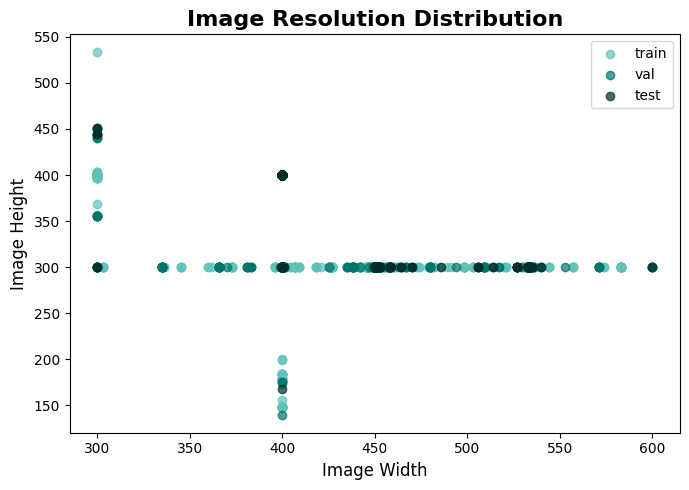

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Plot image resolutions for each split
for i, split in enumerate(splits_order):

    # Select current split data
    subset = df[df["split"] == split]

    # Create scatter plot
    ax.scatter(
        subset["img_w"],
        subset["img_h"],
        color=C[i*2],
        alpha=0.7,
        label=split
    )

# Add title and labels
plt.title(
    "Image Resolution Distribution",
    fontweight='bold',
    fontsize=16
)

plt.xlabel("Image Width", fontsize=12)
plt.ylabel("Image Height", fontsize=12)

# Show legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

The dataset contains images with varying resolutions, although most samples are concentrated around widths of 400–600 pixels and heights near 300 pixels, indicating moderate resolution consistency across all splits.


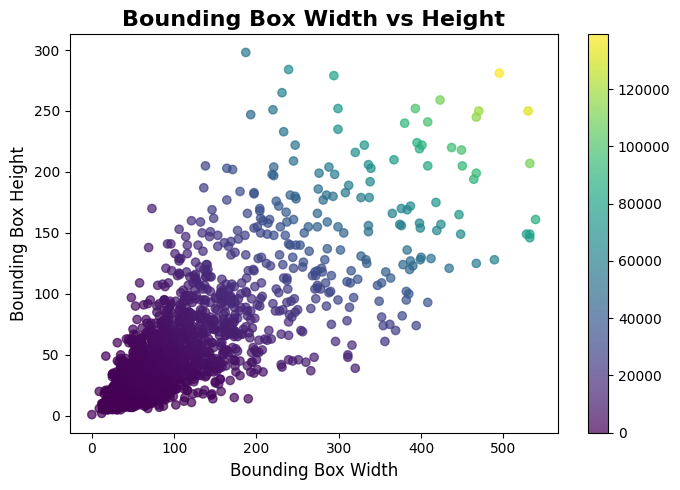

In [ ]:
# Create figure
fig, ax = plt.subplots(figsize=(7,5))

# Create scatter plot
scatter = ax.scatter(
    df["box_w"],
    df["box_h"],
    c=df["area"],
    cmap='viridis',
    alpha=0.7
)

# Add color scale
plt.colorbar(scatter)

# Add title and labels
plt.title(
    "Bounding Box Width vs Height",
    fontweight='bold',
    fontsize=16
)

plt.xlabel("Bounding Box Width", fontsize=12)
plt.ylabel("Bounding Box Height", fontsize=12)

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

The scatter plot shows a positive relationship between bounding box width and height, indicating that larger potholes generally occupy bigger regions in both dimensions within the dataset.


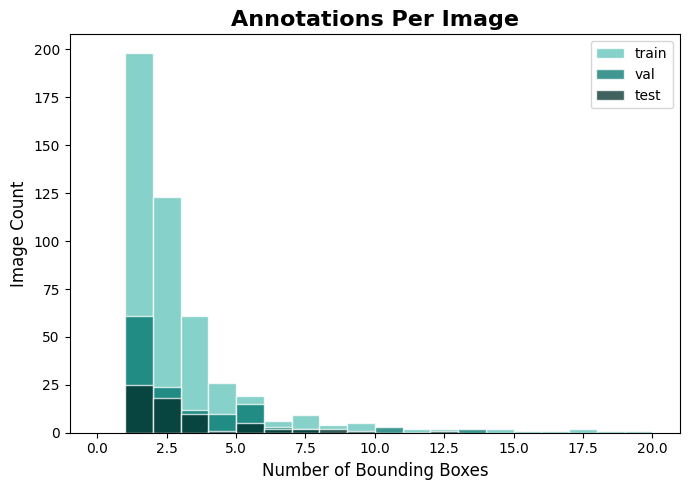

In [ ]:
# Annot per image

records_per_file = []

# Process dataset splits
for split in ["train", "val", "test"]:

    # Read annotation files
    for xml_path in (BASE / split / "annotations").glob("*.xml"):

        # Parse XML file
        root = ET.parse(xml_path).getroot()

        # Count bounding boxes
        n_boxes = len(root.findall("object"))

        # Store record
        records_per_file.append({"split": split, "n_boxes": n_boxes})

# Create dataframe
df_per_file = pd.DataFrame(records_per_file)

# Create figure
fig, ax = plt.subplots(figsize=(7, 5))

# Plot histogram for each split
for i, split in enumerate(["train", "val", "test"]):

    # Select split data
    subset = df_per_file[df_per_file["split"] == split]["n_boxes"]

    # Create histogram
    ax.hist(
        subset,
        bins=range(0, subset.max() + 2),
        alpha=0.75,
        color=C[i * 2],
        edgecolor='white',
        label=split
    )

# Add title
plt.title("Annotations Per Image", fontweight='bold', fontsize=16)

# Add axis labels
plt.xlabel("Number of Bounding Boxes", fontsize=12)
plt.ylabel("Image Count", fontsize=12)

# Show legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

Most images contain only 1 to 3 pothole annotations, while images with a large number of potholes are relatively rare across the train, validation, and test splits.


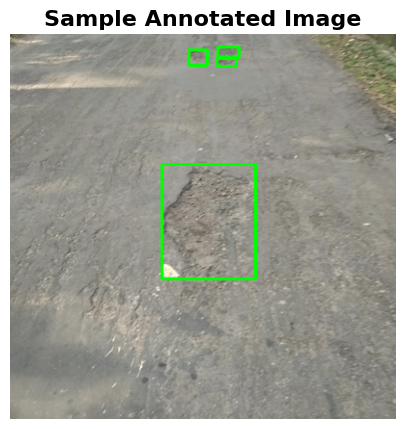

In [ ]:
# Display Sample Image

# Select sample annotation file
sample_xml = list((BASE / "train" / "annotations").glob("*.xml"))[0]

# Create image path
sample_img = BASE / "train" / "images" / f"{sample_xml.stem}.jpg"

# Check PNG fallback
if not sample_img.exists():
    sample_img = sample_img.with_suffix(".png")

# Read image
image = cv2.imread(str(sample_img))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Parse bounding boxes
boxes = parse_xml(sample_xml)

# Draw bounding boxes
for box in boxes:

    xmin, ymin, xmax, ymax = box

    cv2.rectangle(image,
                  (xmin, ymin),
                  (xmax, ymax),
                  (0, 255, 0),
                  2)

# Display image
plt.figure(figsize=(7,5))
plt.imshow(image)

# Add title
plt.title("Sample Annotated Image", fontweight='bold', fontsize=16)

# Hide axes
plt.axis("off")

# Show plot
plt.show()

The sample annotated image demonstrates successful pothole localization using bounding boxes, highlighting pothole regions of varying sizes and positions within the road surface image.


## **Image Preprocessing**

### Image Resizing

Image resizing is a preprocessing technique used to convert all images into a fixed dimension before model training. It ensures consistent input size and improves computational efficiency during deep learning model processing.

Image resizing was applied to maintain uniform image dimensions for YOLOv8, Faster R-CNN, and SSD MobileNet training. It also reduced memory usage and improved training stability and processing speed.


### CLAHE

CLAHE, Contrast Limited Adaptive Histogram Equalization, is an image enhancement technique used to improve local contrast and highlight important image features in different regions of an image.

CLAHE was applied to enhance pothole visibility under varying lighting and road conditions. It helped improve texture details and edge clarity, supporting better pothole feature extraction during detection.


### Normalisation

Image normalisation is a preprocessing technique that scales pixel intensity values into a smaller numerical range, usually between 0 and 1, to improve model learning stability.

Normalisation was applied to reduce intensity variation across images and improve convergence during training. It also helped deep learning models learn features more efficiently and consistently.

In [ ]:
# Resize dimensions for model training
TARGET_SIZE = (640, 640)

In [ ]:
# Preprocessing Function
def preprocess_image(image):

    # Resize
    image = cv2.resize(image, TARGET_SIZE)

    # CLAHE Enhancement
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8) )

    l = clahe.apply(l)

    enhanced = cv2.merge((l, a, b))

    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

    # Normalize
    normalized = enhanced.astype(np.float32) / 255.0

    return normalized

In [ ]:
# Create Output Folders

for split in ["train", "val", "test"]:

    (PREP / split / "images").mkdir( parents=True,exist_ok=True)
    (PREP / split / "annotations").mkdir(parents=True,exist_ok=True)

In [ ]:
# Copy Annotation Files

for split in ["train", "val", "test"]:

    annotation_files = (BASE / split / "annotations").glob("*.xml")

    for xml_file in annotation_files:
        shutil.copy(xml_file, PREP / split / "annotations" / xml_file.name)

In [ ]:
# Preprocess and Save Images

# Process dataset splits
for split in ["train", "val", "test"]:

    # Define input directory
    input_dir = BASE / split / "images"

    # Define output directory
    output_dir = PREP / split / "images"

    # Collect image files
    image_files = list(input_dir.glob("*.jpg")) + \
                  list(input_dir.glob("*.png"))

    # Process images
    for image_path in tqdm(
        image_files,
        desc=f"Processing {split}"
    ):

        # Read image
        image = cv2.imread(str(image_path))

        # Skip invalid images
        if image is None:
            continue

        # Apply preprocessing
        processed = preprocess_image(image)

        # Convert back to uint8
        processed = (processed * 255).astype(np.uint8)

        # Define save path
        save_path = output_dir / f"{image_path.stem}.jpg"

        # Save processed image
        cv2.imwrite(str(save_path), processed)

Processing test: 100%|██████████| 67/67 [00:01<00:00, 33.52it/s]


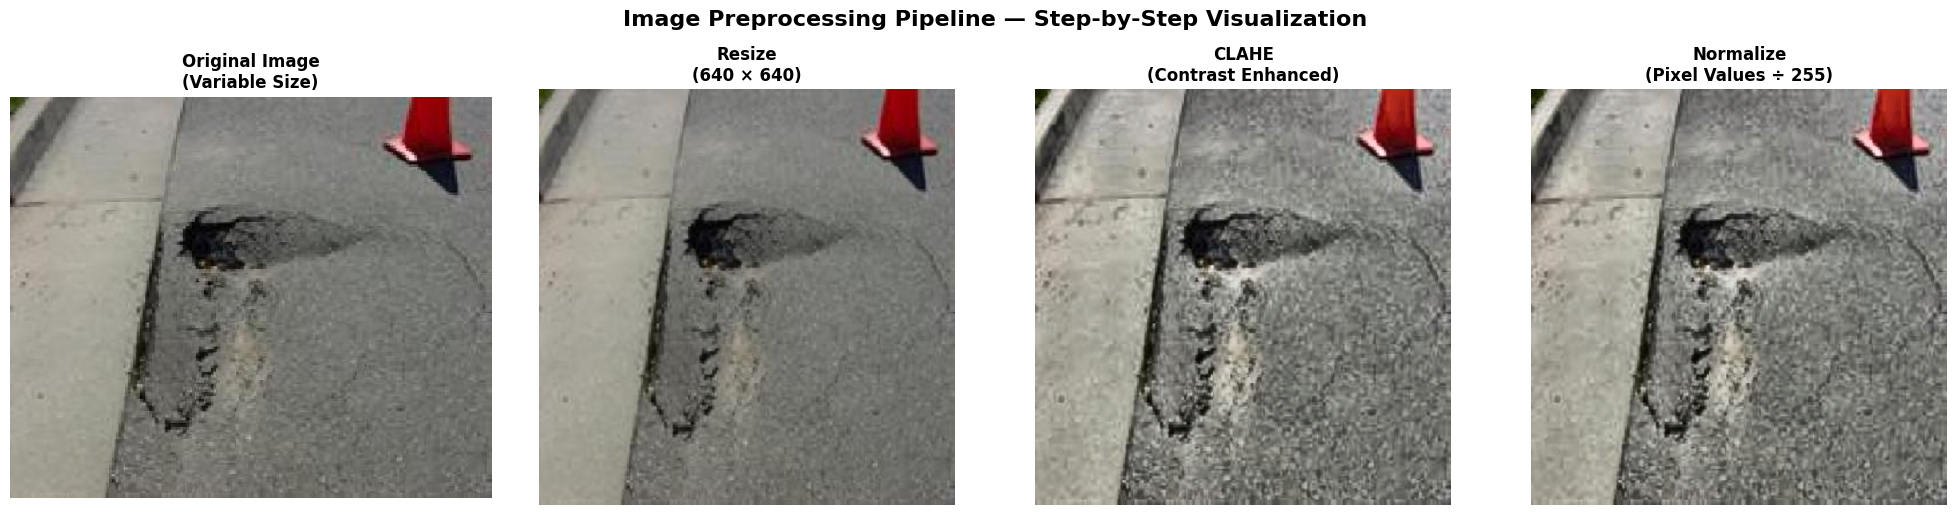

In [ ]:
# Preprocessing Pipeline Visualization

# Find sample image
img_dir = BASE / "train" / "images"

image_files = (
    list(img_dir.glob("*.jpg")) +
    list(img_dir.glob("*.png")) +
    list(img_dir.glob("*.jpeg"))
)

if len(image_files) == 0:
    raise FileNotFoundError(f"No images found in: {img_dir}")

sample_img_path = image_files[10]

# Read image
raw_bgr = cv2.imread(str(sample_img_path))

if raw_bgr is None:
    raise ValueError(f"Failed to load image: {sample_img_path}")

# Convert original image to RGB
raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)


# Resize

step1_bgr = cv2.resize(raw_bgr, TARGET_SIZE)
step1_rgb = cv2.cvtColor(step1_bgr, cv2.COLOR_BGR2RGB)

# CLAHE Enhancement

lab = cv2.cvtColor(step1_bgr, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8, 8))
l_clahe = clahe.apply(l)
lab_clahe = cv2.merge((l_clahe, a, b))

step2_bgr = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
step2_rgb = cv2.cvtColor(step2_bgr, cv2.COLOR_BGR2RGB)

# Normalisation
normalized = step2_bgr.astype(np.float32) / 255.0

# Convert back for visualization only
step3_rgb = (normalized * 255).astype(np.uint8)
step3_rgb = cv2.cvtColor(step3_rgb, cv2.COLOR_BGR2RGB)

# Plot Results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

panels = [
    (
        raw_rgb,
        "Original Image\n(Variable Size)"
    ),
    (
        step1_rgb,
        "Resize\n(640 × 640)"
    ),
    (
        step2_rgb,
        "CLAHE\n(Contrast Enhanced)"
    ),
    (
        step3_rgb,
        "Normalize\n(Pixel Values ÷ 255)"
    ),
]

for ax, (img, title) in zip(axes, panels):

    ax.imshow(img)

    # title
    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold"
    )

    ax.axis("off")

# Main Title
plt.suptitle("Image Preprocessing Pipeline — Step-by-Step Visualization",fontsize=16, fontweight="bold",y=1.02)

# Adjust layout
plt.tight_layout()
# Display Plot
plt.show()

The preprocessing step improved image quality by resizing, enhancing local contrast using CLAHE, and normalizing pixel values, making pothole features more distinct for model training.


## **YOLOv8 Model**

YOLOv8 is a one-stage object detection model developed for fast and accurate real-time object detection. It performs object localisation and classification simultaneously using a unified deep learning architecture, enabling efficient detection of potholes in road images.

YOLOv8 was selected because of its strong balance between detection accuracy and inference speed. The model achieved high precision, F1-score, and Mean IoU while maintaining real-time performance, making it highly suitable for smart road monitoring and automated pothole detection systems.

### YOLO Annotation Conversion

In [ ]:
# Preprocessing output directory
PREP = Path("/kaggle/working/pothole_preprocessed")

# YOLO dataset directory
YOLO_DIR = Path("/kaggle/working/pothole_yolo")

In [ ]:
# Convert Pascal VOC XML annotations to YOLO format
def xml_to_yolo(xml_path, class_id=0):

    # Parse XML file
    tree  = ET.parse(xml_path)
    root  = tree.getroot()

    # Get image dimensions
    img_w = int(root.findtext("size/width")  or 640)
    img_h = int(root.findtext("size/height") or 640)

    lines = []

    # Process bounding boxes
    for obj in root.findall("object"):

        bnd  = obj.find("bndbox")

        xmin = float(bnd.findtext("xmin"))
        ymin = float(bnd.findtext("ymin"))
        xmax = float(bnd.findtext("xmax"))
        ymax = float(bnd.findtext("ymax"))

        # Convert to YOLO format
        cx = ((xmin + xmax) / 2) / img_w
        cy = ((ymin + ymax) / 2) / img_h
        bw = (xmax - xmin) / img_w
        bh = (ymax - ymin) / img_h

        # Clamp values to valid range
        cx, cy, bw, bh = [max(0.0, min(1.0, v)) for v in [cx, cy, bw, bh]]

        # Store annotation line
        lines.append(f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

    return lines

In [ ]:
# Process dataset splits
for split in ["train", "val", "test"]:

    # Define output directories
    img_out   = YOLO_DIR / split / "images"
    label_out = YOLO_DIR / split / "labels"

    # Create directories
    img_out.mkdir(parents=True, exist_ok=True)
    label_out.mkdir(parents=True, exist_ok=True)

    # Copy preprocessed images
    for img in (PREP / split / "images").glob("*.jpg"):
        shutil.copy(img, img_out / img.name)

    # Convert XML annotations to YOLO format
    for xml in (PREP / split / "annotations").glob("*.xml"):

        lines = xml_to_yolo(xml)

        # Create label file path
        txt_path = label_out / (xml.stem + ".txt")

        # Save YOLO labels
        txt_path.write_text("\n".join(lines))

    # Count label files
    count = len(list(label_out.glob("*.txt")))

    # Display summary
    print(f"{split:>6}  —  {count} label files written")

 train  —  465 label files written
   val  —  133 label files written
  test  —  67 label files written


In [ ]:
# Create YOLO dataset configuration file
yaml_text = (
    # Dataset root path
    f"path: {YOLO_DIR.resolve()}\n"

    # Training images path
    f"train: train/images\n"

    # Validation images path
    f"val:   val/images\n"

    # Test images path
    f"test:  test/images\n\n"

    # Number of classes
    f"nc: 1\n"

    # Class names
    f"names:\n"
    f"  - pothole\n"
)

# Define YAML file path
yaml_path = YOLO_DIR / "pothole.yaml"
# Save YAML file
yaml_path.write_text(yaml_text)
# Display file location
print("YAML saved at:", yaml_path)
print()
# Display YAML content
print(yaml_text)

YAML saved at: /kaggle/working/pothole_yolo/pothole.yaml

path: /kaggle/working/pothole_yolo
train: train/images
val:   val/images
test:  test/images

nc: 1
names:
  - pothole



### Model Training

In [ ]:
# Shared hyperparameters
SHARED_EPOCHS    = 15
SHARED_IMGSZ     = 640      # input size
SHARED_BATCH     = 4        # limited by Faster R-CNN memory
CONF_THRESH      = 0.4  # confidence threshold
IOU_THRESH       = 0.50

In [ ]:
# YOLOv8 Training

model = YOLO("yolov8s.pt")

model.train(
    data      = str(yaml_path.resolve()),
    epochs    = SHARED_EPOCHS,
    imgsz     = SHARED_IMGSZ,
    batch     = SHARED_BATCH,
    name      = "yolo_pothole",
    project   = "/kaggle/working/runs/yolo",
    patience  = 10,
    workers   = 4,
    verbose   = False,
    seed      = 42                   # explicit seed
)

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/pothole_yolo/pothole.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_pothole-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fd62f011be0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# Load Best YOLO Weights

run_dirs = sorted(glob.glob("/kaggle/working/runs/yolo/yolo_pothole*/weights/best.pt"))
best_weights = Path(run_dirs[-1])  # pick the latest

yolo_eval = YOLO(str(best_weights))
print("Best model loaded from:", best_weights)

Best model loaded from: /kaggle/working/runs/yolo/yolo_pothole/weights/best.pt


In [ ]:
# download model
import shutil
from pathlib import Path

best_model = Path(
    "/kaggle/working/runs/yolo/yolo_pothole/weights/best.pt"
)

download_path = Path(
    "/kaggle/working/best.pt"
)

shutil.copy(
    best_model,
    download_path
)

print("Model ready for download:")
print(download_path)

Model ready for download:
/kaggle/working/best.pt


In [ ]:
# YOLOv8 Inference

# Collect test images
test_imgs = list((YOLO_DIR / "test" / "images").glob("*.jpg"))

# Run YOLOv8 prediction
yolo_results = yolo_eval.predict(
    source = [str(p) for p in test_imgs],
    conf   = CONF_THRESH,
    iou    = IOU_THRESH,
    verbose = False
)

# Display inference summary
print(f"YOLO inference complete on {len(yolo_results)} test images.")

YOLO inference complete on 67 test images.


In [ ]:
# Find YOLO training result files
csv_dirs = sorted(
    glob.glob("/kaggle/working/runs/yolo/yolo_pothole*/results.csv")
)

# Load latest results file
results_csv = pd.read_csv(csv_dirs[-1])

# Display loaded file path
print("Loaded results from:", csv_dirs[-1])

Loaded results from: /kaggle/working/runs/yolo/yolo_pothole/results.csv


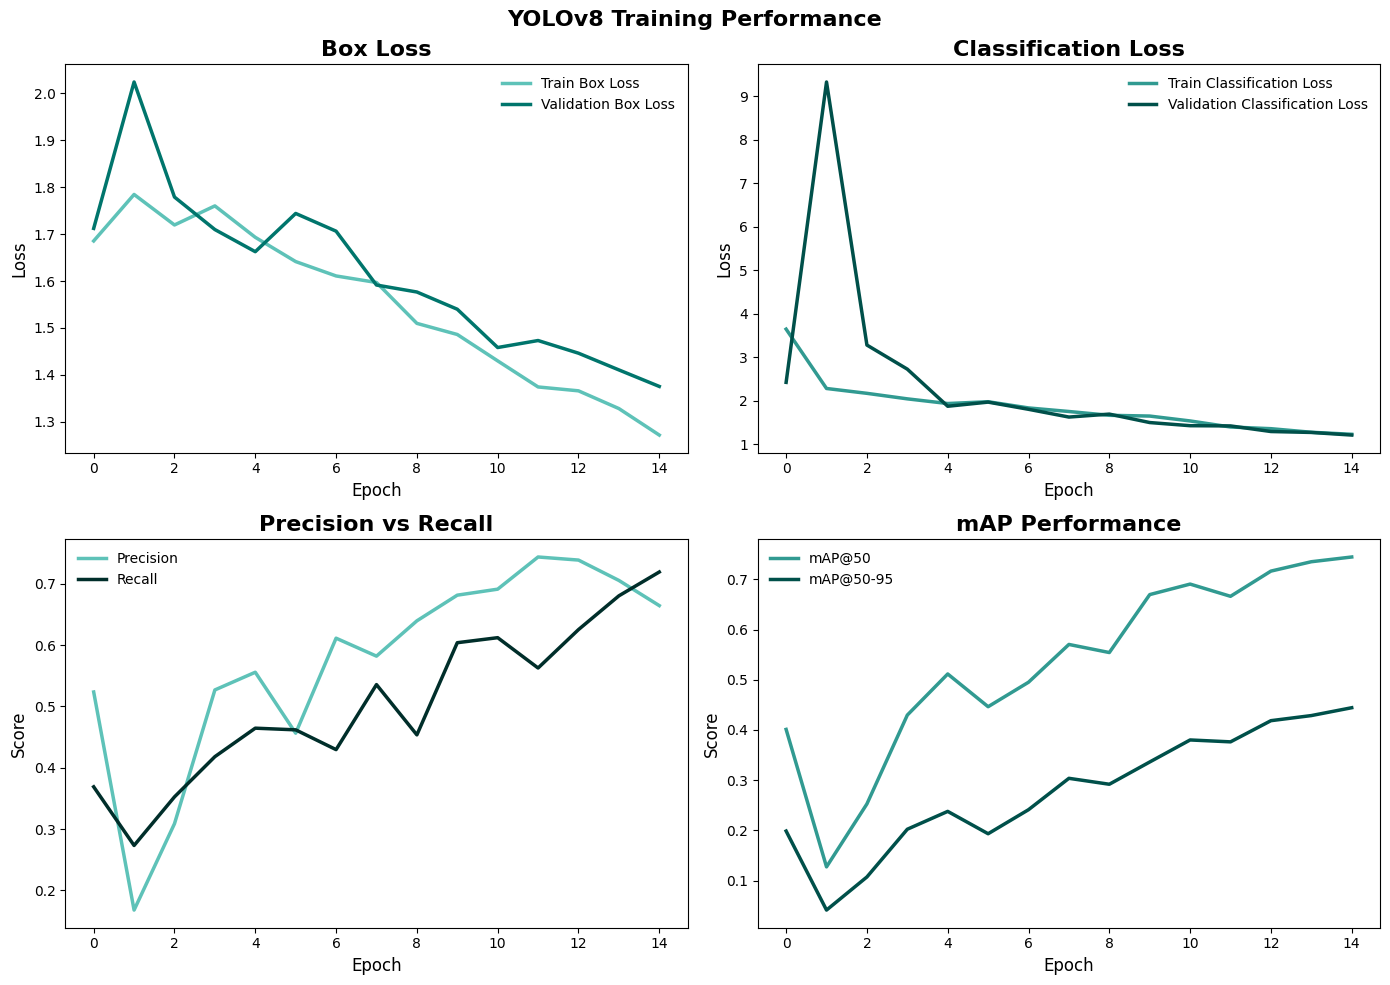

In [ ]:
# YOLOv8 Training and Validation Curves

# Create subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

# Box Loss
axes[0].plot(results_csv["train/box_loss"], label="Train Box Loss", linewidth=2.5, color=C[0])
axes[0].plot(results_csv["val/box_loss"], label="Validation Box Loss", linewidth=2.5, color=C[2])

axes[0].set_title("Box Loss", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].legend(frameon=False)

# Classification Loss
axes[1].plot(results_csv["train/cls_loss"], label="Train Classification Loss", linewidth=2.5, color=C[1])
axes[1].plot(results_csv["val/cls_loss"], label="Validation Classification Loss", linewidth=2.5, color=C[3])

axes[1].set_title("Classification Loss", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Loss", fontsize=12)
axes[1].legend(frameon=False)

# Precision and Recall
axes[2].plot(results_csv["metrics/precision(B)"], label="Precision", linewidth=2.5, color=C[0])
axes[2].plot(results_csv["metrics/recall(B)"], label="Recall", linewidth=2.5, color=C[4])

axes[2].set_title("Precision vs Recall", fontsize=16, fontweight='bold')
axes[2].set_xlabel("Epoch", fontsize=12)
axes[2].set_ylabel("Score", fontsize=12)
axes[2].legend(frameon=False)

# mAP Metrics
axes[3].plot(results_csv["metrics/mAP50(B)"], label="mAP@50", linewidth=2.5, color=C[1])
axes[3].plot(results_csv["metrics/mAP50-95(B)"], label="mAP@50-95", linewidth=2.5, color=C[3])

axes[3].set_title("mAP Performance", fontsize=16, fontweight='bold')
axes[3].set_xlabel("Epoch", fontsize=12)
axes[3].set_ylabel("Score", fontsize=12)
axes[3].legend(frameon=False)

# Add overall title
plt.suptitle("YOLOv8 Training Performance", fontsize=16, fontweight='bold')

# Adjust layout
plt.tight_layout()

# Display plots
plt.show()

YOLOv8 training showed consistent improvement across 15 epochs, with box and classification losses steadily decreasing while precision, recall and mAP scores increased significantly. Final results achieved 0.744 mAP@50 and 0.719 recall, indicating strong pothole detection capability with stable learning behaviour, good localisation accuracy and effective generalisation on validation data.

In [ ]:
# IoU Function

def iou_single(boxA, boxB):

    # Intersection coordinates
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])

    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # Intersection area
    inter_area = max(0, xB - xA) * max(0, yB - yA)

    # Box areas
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])

    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # Union area
    union_area = areaA + areaB - inter_area

    # IoU
    return inter_area / union_area if union_area > 0 else 0.0


In [ ]:
# Load ground truth bounding boxes
def load_gt_boxes(img_stem, label_dir, img_w, img_h):

    # Define label file path
    txt_path = label_dir / f"{img_stem}.txt"

    boxes = []

    # Check label file
    if txt_path.exists():

        # Read annotation lines
        lines = txt_path.read_text().strip().splitlines()

        # Process annotations
        for line in lines:

            parts = list(map(float, line.split()))

            # Extract YOLO coordinates
            cx, cy, bw, bh = parts[1:]

            # Convert to corner format
            xmin = int((cx - bw / 2) * img_w)
            ymin = int((cy - bh / 2) * img_h)

            xmax = int((cx + bw / 2) * img_w)
            ymax = int((cy + bh / 2) * img_h)

            # Store bounding box
            boxes.append([xmin, ymin, xmax, ymax])

    return boxes

In [ ]:
# Evaluation Settings

label_dir = YOLO_DIR / "test" / "labels"

tp = 0
fp = 0
fn = 0

iou_scores = []

In [ ]:
# YOLOv8 Evaluation on Test Set

# Test Images

test_imgs = list(
    (YOLO_DIR / "test" / "images").glob("*.jpg")
)

# Run Evaluation

for img_path, res in zip(test_imgs, yolo_results):

    # Read image
    img = cv2.imread(str(img_path))

    if img is None:
        continue

    h, w = img.shape[:2]

    # Ground truth boxes
    gt_boxes = load_gt_boxes(
        img_path.stem,
        label_dir,
        w,
        h
    )

    # Predicted boxes
    pred_boxes = (
        res.boxes.xyxy.cpu().numpy().tolist()
        if res.boxes else []
    )

    matched_gt = set()

    # Compare predictions with GT
    for pb in pred_boxes:

        best_iou = 0
        best_gi = -1

        for gi, gb in enumerate(gt_boxes):

            score = iou_single(pb, gb)

            if score > best_iou:

                best_iou = score
                best_gi = gi

        # True Positive
        if best_iou >= IOU_THRESH and best_gi not in matched_gt:

            tp += 1

            matched_gt.add(best_gi)

            iou_scores.append(best_iou)

        # False Positive
        else:

            fp += 1

    # False Negatives
    fn += len(gt_boxes) - len(matched_gt)

# Final Metrics

precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)
f1 = 2 * precision * recall / (
    precision + recall + 1e-6)
mean_iou = (
    float(np.mean(iou_scores))
    if iou_scores else 0.0)

In [ ]:
# Display Results

print("YOLOv8 — Test Set Results:")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Mean IoU  : {mean_iou:.4f}")

print(f"TP = {tp}   FP = {fp}   FN = {fn}")

YOLOv8 — Test Set Results:
Precision : 0.8750
Recall    : 0.5652
F1-score  : 0.6868
Mean IoU  : 0.8342
TP = 91   FP = 13   FN = 70


YOLOv8 achieved high precision of 0.8750 and strong IoU of 0.8342, showing accurate pothole detection with few false positives. The model correctly detected 91 potholes, but recall of 0.5652 and 70 false negatives indicate that some potholes were missed during detection.

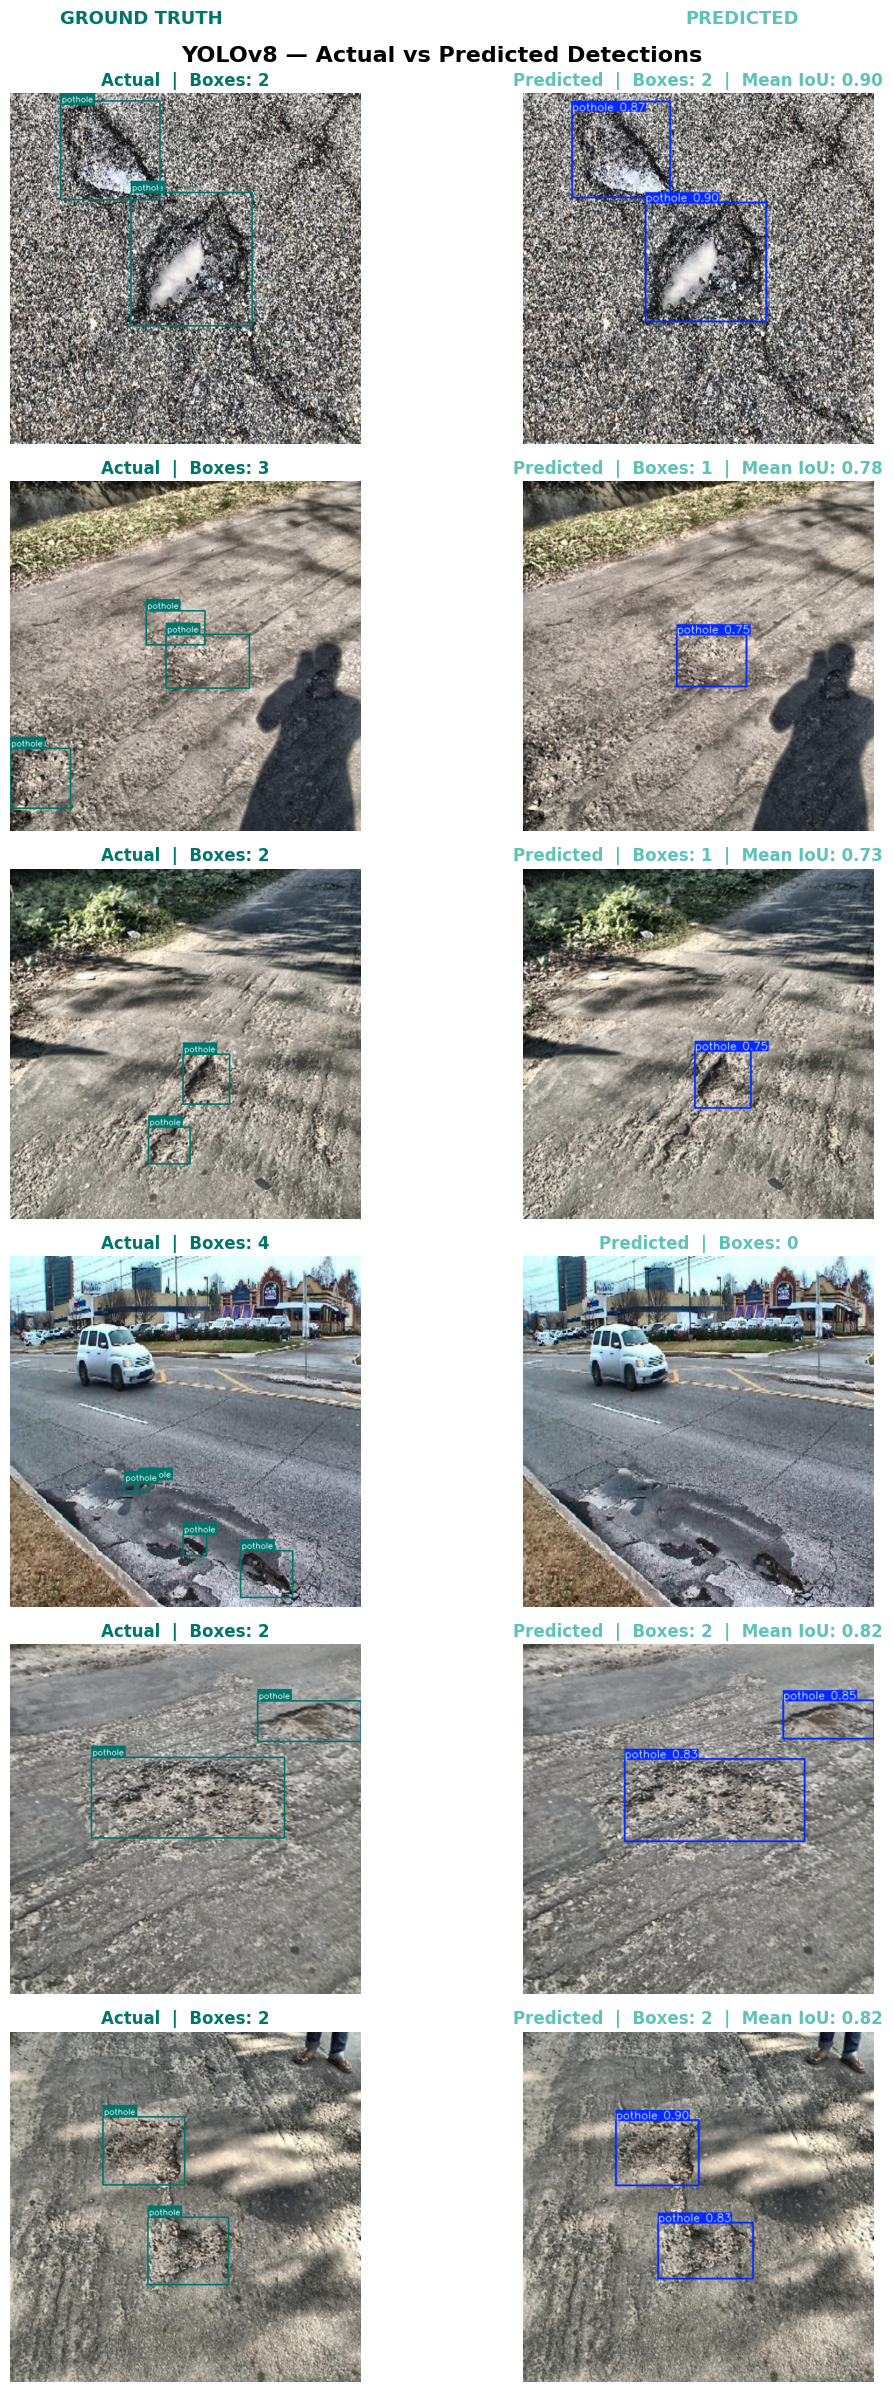

In [ ]:
# YOLOv8 — Actual vs Predicted Visualization

# Select sample test images
NUM_YOLO = 6
test_img_list = list((YOLO_DIR / "test" / "images").glob("*.jpg"))
sample_imgs   = random.sample(test_img_list, NUM_YOLO)

# Create subplot layout
fig, axes = plt.subplots(NUM_YOLO, 2, figsize=(12, NUM_YOLO * 4))

# Run YOLOv8 predictions
yolo_sample_results = yolo_eval.predict(
    source  = [str(p) for p in sample_imgs],
    conf    = CONF_THRESH,
    iou     = IOU_THRESH,
    verbose = False
)

# Process images
for row, (img_path, result) in enumerate(
    zip(sample_imgs, yolo_sample_results)
):

    # Ground Truth
    raw = cv2.imread(str(img_path))
    raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    h, w = raw.shape[:2]

    # Load ground truth boxes
    gt_boxes = load_gt_boxes(img_path.stem, YOLO_DIR / "test" / "labels", w, h)

    gt_img = raw.copy()

    # Draw ground truth boxes
    for box in gt_boxes:

        x1, y1, x2, y2 = [int(v) for v in box]

        cv2.rectangle(gt_img, (x1, y1), (x2, y2), (0, 117, 108), 2)

        (tw, th), bl = cv2.getTextSize(
            "pothole",
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            1
        )

        ty = max(y1 - 4, th + 4)

        cv2.rectangle(
            gt_img,
            (x1, ty - th - bl),
            (x1 + tw + 4, ty + bl),
            (0, 117, 108),
            -1
        )

        cv2.putText(
            gt_img,
            "pothole",
            (x1 + 2, ty),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )

    # Display ground truth image
    axes[row, 0].imshow(gt_img)

    axes[row, 0].set_title(
        f"Actual  |  Boxes: {len(gt_boxes)}",
        fontsize=12,
        fontweight='bold',
        color=C[2]
    )

    axes[row, 0].axis("off")

    # Predictions
    pred_img = result.plot()
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    pred_boxes = result.boxes.xyxy.cpu().numpy().tolist() if result.boxes else []
    pred_confs = result.boxes.conf.cpu().numpy().tolist() if result.boxes else []

    # Calculate IoU
    if gt_boxes and pred_boxes:

        best_ious = [
            max((iou_single(pb, gb) for gb in gt_boxes), default=0.0)
            for pb in pred_boxes
        ]

        mean_iou_img = np.mean(best_ious)

        right_title  = (
            f"Predicted  |  Boxes: {len(pred_boxes)}  |  "
            f"Mean IoU: {mean_iou_img:.2f}"
        )

    else:
        right_title = f"Predicted  |  Boxes: {len(pred_boxes)}"

    # Display prediction image
    axes[row, 1].imshow(pred_img)

    axes[row, 1].set_title(
        right_title,
        fontsize=12,
        fontweight='bold',
        color=C[0]
    )

    axes[row, 1].axis("off")

# Add column headings
fig.text(
    0.25,
    0.995,
    "GROUND TRUTH",
    ha='center',
    va='top',
    fontsize=13,
    fontweight='bold',
    color=C[2]
)

fig.text(
    0.75,
    0.995,
    "PREDICTED",
    ha='center',
    va='top',
    fontsize=13,
    fontweight='bold',
    color=C[0]
)

# Add overall title
plt.suptitle(
    "YOLOv8 — Actual vs Predicted Detections",
    fontsize=16,
    fontweight='bold'
)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.99])

# Display plot
plt.show()

The visual results show that YOLOv8 accurately detected potholes in most road images with high IoU scores and confidence values. The model performed well on clear pothole regions, but missed some small or complex potholes in challenging scenes, indicating limitations in detecting low-visibility and distant road damages.